# 🎯 TravelMate AI - 23 Personalized Hybrid Ranker

Notebook 22 showed an important result:

```text
MMR diversity ↑
but
preference alignment ↓
personalization ↓
coverage ↓
```

So we rejected MMR as the default production ranking strategy.

Now we improve the **scoring layer** instead.

## Idea

The current hybrid rank combines:

```text
Structured preference score
TF-IDF score
Semantic score
Rating
Popularity
```

This notebook introduces a **profile-aware weighting strategy**.

The goal is:

```text
User profile
    ↓
Identify strongest interests
    ↓
Adjust ranking weights
    ↓
Personalized hybrid score
    ↓
More preference-aligned recommendations
```

This is still an interpretable heuristic ranker, not a newly trained supervised model.


## 1. Imports and setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_places, available_cities
from src.recommender import TravelRecommender

print("✅ Environment ready")


d:\college_work\PG\linkedIn_projects\TravelMate-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment ready


## 2. Load data and shared recommender

In [2]:
df = load_places()

embedding_path = (
    PROJECT_ROOT
    / "data"
    / "embeddings"
    / "multi_city_place_embeddings.npy"
)

embeddings = None

if embedding_path.exists():
    candidate = np.load(embedding_path)

    if len(candidate) == len(df):
        embeddings = candidate
        print("✅ Loaded multi-city embeddings")
    else:
        print("⚠️ Embedding row count mismatch")

recommender = TravelRecommender(
    df=df,
    place_embeddings=embeddings
)

print("Dataset:", df.shape)
print("Cities:", available_cities(df))


✅ Loaded multi-city embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6939.30it/s]


Dataset: (120, 27)
Cities: ['Goa', 'Jaipur', 'Manali', 'Rishikesh', 'Shimla', 'Udaipur']


## 3. Traveller profiles and queries

In [3]:
PROFILES = {
    "nature_photographer": {
        "nature": 1.0,
        "history": 0.1,
        "culture": 0.2,
        "adventure": 0.4,
        "photography": 1.0,
        "shopping": 0.1,
        "religious": 0.0,
        "family": 0.3,
    },
    "history_culture": {
        "nature": 0.1,
        "history": 1.0,
        "culture": 1.0,
        "adventure": 0.0,
        "photography": 0.8,
        "shopping": 0.3,
        "religious": 0.3,
        "family": 0.3,
    },
    "adventure": {
        "nature": 0.7,
        "history": 0.1,
        "culture": 0.1,
        "adventure": 1.0,
        "photography": 0.5,
        "shopping": 0.0,
        "religious": 0.0,
        "family": 0.2,
    },
    "family": {
        "nature": 0.7,
        "history": 0.2,
        "culture": 0.3,
        "adventure": 0.1,
        "photography": 0.4,
        "shopping": 0.2,
        "religious": 0.1,
        "family": 1.0,
    },
    "shopping_culture": {
        "nature": 0.1,
        "history": 0.5,
        "culture": 0.8,
        "adventure": 0.0,
        "photography": 0.4,
        "shopping": 1.0,
        "religious": 0.2,
        "family": 0.3,
    },
}

QUERIES = {
    "nature_photographer":
        "peaceful scenic places surrounded by nature for photography",
    "history_culture":
        "historical cultural forts palaces temples and heritage places",
    "adventure":
        "adventure trekking outdoor and exciting travel experiences",
    "family":
        "family friendly relaxing places and activities",
    "shopping_culture":
        "local markets shopping and cultural experiences",
}

FEATURE_COLUMNS = [
    "nature",
    "history",
    "culture",
    "adventure",
    "photography",
    "shopping",
    "religious",
    "family",
]


## 4. Define the personalized weighting strategy

Base weights remain interpretable:

```text
Semantic      30%
Structured    25%
TF-IDF        25%
Rating        10%
Popularity    10%
```

Then a portion of the structured weight is increased according to the user's strongest interests.

This gives the model a stronger signal that:

```text
photography-focused user
≠
history-focused user
≠
adventure-focused user
```


In [4]:
BASE_WEIGHTS = {
    "structured": 0.25,
    "tfidf": 0.25,
    "semantic": 0.30,
    "rating": 0.10,
    "popularity": 0.10,
}


def get_personalized_weights(
    preferences,
    emphasis=0.15,
):
    preferences = {
        key: float(value)
        for key, value in preferences.items()
    }

    total = sum(
        max(value, 0.0)
        for value in preferences.values()
    )

    if total <= 0:
        return BASE_WEIGHTS.copy()

    # Stronger preference profile gets a stronger
    # structured-signal contribution.
    structured_boost = (
        emphasis
        * min(
            total / len(preferences),
            1.0
        )
    )

    weights = BASE_WEIGHTS.copy()

    weights["structured"] += structured_boost
    weights["semantic"] -= structured_boost * 0.5
    weights["tfidf"] -= structured_boost * 0.5

    return weights


for profile_name, profile in PROFILES.items():

    print(
        profile_name,
        get_personalized_weights(profile)
    )


nature_photographer {'structured': 0.308125, 'tfidf': 0.2209375, 'semantic': 0.2709375, 'rating': 0.1, 'popularity': 0.1}
history_culture {'structured': 0.32125, 'tfidf': 0.214375, 'semantic': 0.26437499999999997, 'rating': 0.1, 'popularity': 0.1}
adventure {'structured': 0.29875, 'tfidf': 0.225625, 'semantic': 0.275625, 'rating': 0.1, 'popularity': 0.1}
family {'structured': 0.30625, 'tfidf': 0.221875, 'semantic': 0.271875, 'rating': 0.1, 'popularity': 0.1}
shopping_culture {'structured': 0.311875, 'tfidf': 0.2190625, 'semantic': 0.2690625, 'rating': 0.1, 'popularity': 0.1}


## 5. Build a preference-specific structured score

In [5]:
def minmax(values):
    values = np.asarray(
        values,
        dtype=float
    )

    if len(values) == 0:
        return values

    lo = values.min()
    hi = values.max()

    if lo == hi:
        return np.ones_like(values)

    return (
        (values - lo)
        / (hi - lo)
    )


def personalized_structured_score(
    result,
    preferences,
):
    matrix = (
        result[
            FEATURE_COLUMNS
        ]
        .fillna(0)
        .astype(float)
        .to_numpy()
    )

    preference_vector = np.array(
        [
            preferences[column]
            for column in FEATURE_COLUMNS
        ],
        dtype=float
    )

    numerator = (
        matrix
        @ preference_vector
    )

    denominator = (
        np.linalg.norm(
            matrix,
            axis=1
        )
        * np.linalg.norm(
            preference_vector
        )
    )

    score = np.zeros(
        len(result),
        dtype=float
    )

    valid = denominator > 0

    score[valid] = (
        numerator[valid]
        / denominator[valid]
    )

    return score


## 6. Create baseline and personalized scores

In [6]:
def score_baseline(
    result
):
    result = result.copy()

    result["baseline_score"] = (
        BASE_WEIGHTS["structured"]
        * result["structured_score"]
        + BASE_WEIGHTS["tfidf"]
        * result["tfidf_score"]
        + BASE_WEIGHTS["semantic"]
        * result["semantic_score"]
        + BASE_WEIGHTS["rating"]
        * result["rating_score"]
        + BASE_WEIGHTS["popularity"]
        * result["popularity_score"]
    )

    return result


def score_personalized(
    result,
    preferences,
):
    result = result.copy()

    weights = get_personalized_weights(
        preferences
    )

    result["personalized_structured_score"] = (
        personalized_structured_score(
            result,
            preferences
        )
    )

    result["personalized_score"] = (
        weights["structured"]
        * result[
            "personalized_structured_score"
        ]
        + weights["tfidf"]
        * result["tfidf_score"]
        + weights["semantic"]
        * result["semantic_score"]
        + weights["rating"]
        * result["rating_score"]
        + weights["popularity"]
        * result["popularity_score"]
    )

    return result


## 7. Single-city comparison

In [7]:
city = "Goa"
profile_name = "nature_photographer"

base = recommender.recommend(
    destination=city,
    query=QUERIES[profile_name],
    user_preferences=PROFILES[profile_name],
    top_n=12,
)

# Recalculate the baseline score explicitly.
base = score_baseline(base)

personalized = score_personalized(
    base,
    PROFILES[profile_name]
)

baseline_top = (
    personalized
    .sort_values(
        "baseline_score",
        ascending=False
    )
    .head(5)
)

personalized_top = (
    personalized
    .sort_values(
        "personalized_score",
        ascending=False
    )
    .head(5)
)

print("BASELINE")
display(
    baseline_top[
        [
            "name",
            "travel_tags",
            "baseline_score",
        ]
    ]
)

print("\nPERSONALIZED")
display(
    personalized_top[
        [
            "name",
            "travel_tags",
            "personalized_score",
        ]
    ]
)


BASELINE


,name,travel_tags,baseline_score
0,"Calangute Beach, Goa","nature, photography, family",0.705499
1,Keri Beach,"nature, photography, family",0.680005
2,Kuske Waterfall,"nature, photography",0.663103
3,Twin Waterfall,"nature, photography",0.638201
4,Kesarval Spring Verna Waterfall,"nature, photography",0.587110



PERSONALIZED


,name,travel_tags,personalized_score
0,"Calangute Beach, Goa","nature, photography, family",0.721240
1,Keri Beach,"nature, photography, family",0.697653
2,Kuske Waterfall,"nature, photography",0.682587
3,Twin Waterfall,"nature, photography",0.656524
4,Kesarval Spring Verna Waterfall,"nature, photography",0.611283


## 8. Compare preference alignment

We explicitly measure the proxy that became weaker with MMR.



In [8]:
def preference_alignment(
    result,
    preferences,
):
    matrix = (
        result[
            FEATURE_COLUMNS
        ]
        .fillna(0)
        .astype(float)
        .to_numpy()
    )

    preference = np.array(
        [
            preferences[column]
            for column in FEATURE_COLUMNS
        ],
        dtype=float
    )

    denominator = (
        np.linalg.norm(
            matrix,
            axis=1
        )
        * np.linalg.norm(
            preference
        )
    )

    scores = np.zeros(
        len(matrix)
    )

    valid = denominator > 0

    scores[valid] = (
        matrix[valid]
        @ preference
    ) / denominator[valid]

    return float(
        scores.mean()
    )


baseline_alignment = preference_alignment(
    baseline_top,
    PROFILES[profile_name],
)

personalized_alignment = preference_alignment(
    personalized_top,
    PROFILES[profile_name],
)

print(
    "Baseline alignment:",
    round(
        baseline_alignment,
        4
    )
)

print(
    "Personalized alignment:",
    round(
        personalized_alignment,
        4
    )
)


Baseline alignment: 0.9078
Personalized alignment: 0.9078


# 🧪 9. Evaluate all cities and profiles

This is the important experiment.

We compare baseline and personalized ranking across the complete evaluation matrix:

```text
6 cities × 5 traveller profiles
```


In [9]:
rows = []

for city in available_cities(df):

    for profile_name, preferences in PROFILES.items():

        result = recommender.recommend(
            destination=city,
            query=QUERIES[profile_name],
            user_preferences=preferences,
            top_n=10,
        )

        result = score_baseline(
            result
        )

        result = score_personalized(
            result,
            preferences
        )

        baseline_top = (
            result
            .sort_values(
                "baseline_score",
                ascending=False
            )
            .head(5)
        )

        personalized_top = (
            result
            .sort_values(
                "personalized_score",
                ascending=False
            )
            .head(5)
        )

        rows.append({
            "city": city,
            "profile": profile_name,

            "baseline_alignment":
                preference_alignment(
                    baseline_top,
                    preferences,
                ),

            "personalized_alignment":
                preference_alignment(
                    personalized_top,
                    preferences,
                ),

            "baseline_mean_score":
                baseline_top[
                    "baseline_score"
                ].mean(),

            "personalized_mean_score":
                personalized_top[
                    "personalized_score"
                ].mean(),

            "baseline_city_correct":
                float(
                    baseline_top["city"]
                    .eq(city)
                    .all()
                ),

            "personalized_city_correct":
                float(
                    personalized_top["city"]
                    .eq(city)
                    .all()
                ),
        })

comparison_df = pd.DataFrame(rows)

comparison_df


,city,profile,baseline_alignment,personalized_alignment,baseline_mean_score,personalized_mean_score,baseline_city_correct,personalized_city_correct
0,Goa,nature_photographer,0.907770,0.907770,0.654783,0.673857,1.0,1.0
1,Goa,history_culture,0.912245,0.946032,0.613078,0.649111,1.0,1.0
2,Goa,adventure,0.620898,0.620898,0.542552,0.550740,1.0,1.0
3,Goa,family,0.665039,0.703109,0.597957,0.607640,1.0,1.0
4,Goa,shopping_culture,0.639825,0.639825,0.511929,0.528883,1.0,1.0
5,Jaipur,nature_photographer,0.592000,0.592000,0.596102,0.601100,1.0,1.0
6,Jaipur,history_culture,0.946032,0.946032,0.643162,0.680450,1.0,1.0
7,Jaipur,adventure,0.396100,0.396100,0.495327,0.494550,1.0,1.0
8,Jaipur,family,0.771201,0.771201,0.623019,0.636610,1.0,1.0
9,Jaipur,shopping_culture,0.663233,0.663233,0.549955,0.567080,1.0,1.0


## 10. Aggregate results

In [10]:
summary = pd.DataFrame({
    "metric": [
        "Preference alignment",
        "Mean recommendation score",
        "City correctness",
    ],

    "baseline": [
        comparison_df[
            "baseline_alignment"
        ].mean(),

        comparison_df[
            "baseline_mean_score"
        ].mean(),

        comparison_df[
            "baseline_city_correct"
        ].mean(),
    ],

    "personalized": [
        comparison_df[
            "personalized_alignment"
        ].mean(),

        comparison_df[
            "personalized_mean_score"
        ].mean(),

        comparison_df[
            "personalized_city_correct"
        ].mean(),
    ],
})

summary["change"] = (
    summary["personalized"]
    - summary["baseline"]
)

summary


,metric,baseline,personalized,change
0,Preference alignment,0.672733,0.684515,0.011782
1,Mean recommendation score,0.554864,0.568926,0.014061
2,City correctness,1.000000,1.000000,0.000000


# 🧠 11. Personalization sensitivity

We compare how different traveller profiles rank the same destination.

A useful personalized ranker should produce meaningfully different rankings for meaningfully different preferences.


In [11]:
profile_pairs = [
    (
        "nature_photographer",
        "history_culture",
    ),
    (
        "nature_photographer",
        "adventure",
    ),
    (
        "family",
        "shopping_culture",
    ),
]


def jaccard(
    set_a,
    set_b,
):
    union = set_a | set_b

    if not union:
        return 1.0

    return (
        len(set_a & set_b)
        / len(union)
    )


sensitivity_rows = []

for city in available_cities(df):

    for profile_a, profile_b in profile_pairs:

        result_a = recommender.recommend(
            destination=city,
            query=QUERIES[profile_a],
            user_preferences=PROFILES[profile_a],
            top_n=10,
        )

        result_b = recommender.recommend(
            destination=city,
            query=QUERIES[profile_b],
            user_preferences=PROFILES[profile_b],
            top_n=10,
        )

        result_a = score_personalized(
            score_baseline(result_a),
            PROFILES[profile_a],
        )

        result_b = score_personalized(
            score_baseline(result_b),
            PROFILES[profile_b],
        )

        names_a = set(
            result_a
            .sort_values(
                "personalized_score",
                ascending=False
            )
            .head(5)["name"]
        )

        names_b = set(
            result_b
            .sort_values(
                "personalized_score",
                ascending=False
            )
            .head(5)["name"]
        )

        similarity = jaccard(
            names_a,
            names_b
        )

        sensitivity_rows.append({
            "city": city,
            "profile_a": profile_a,
            "profile_b": profile_b,
            "ranking_change":
                1.0 - similarity,
        })

sensitivity_df = pd.DataFrame(
    sensitivity_rows
)

sensitivity_df


,city,profile_a,profile_b,ranking_change
0,Goa,nature_photographer,history_culture,1.000000
1,Goa,nature_photographer,adventure,0.571429
2,Goa,family,shopping_culture,0.888889
3,Jaipur,nature_photographer,history_culture,0.571429
4,Jaipur,nature_photographer,adventure,0.333333
5,Jaipur,family,shopping_culture,1.000000
6,Manali,nature_photographer,history_culture,0.888889
7,Manali,nature_photographer,adventure,0.888889
8,Manali,family,shopping_culture,1.000000
9,Rishikesh,nature_photographer,history_culture,0.571429


## 12. Compare personalization sensitivity

In [12]:
print(
    "Mean ranking change:",
    round(
        sensitivity_df[
            "ranking_change"
        ].mean(),
        4
    )
)


Mean ranking change: 0.6872


# 📈 13. Profile-level analysis

This tells us whether the personalized weighting helps all traveller profiles equally.


In [13]:
profile_summary = (
    comparison_df
    .groupby("profile")[
        [
            "baseline_alignment",
            "personalized_alignment",
        ]
    ]
    .mean()
    .reset_index()
)

profile_summary["alignment_change"] = (
    profile_summary[
        "personalized_alignment"
    ]
    - profile_summary[
        "baseline_alignment"
    ]
)

profile_summary


,profile,baseline_alignment,personalized_alignment,alignment_change
0,adventure,0.548008,0.582645,0.034637
1,family,0.729928,0.736273,0.006345
2,history_culture,0.740448,0.746079,0.005631
3,nature_photographer,0.789987,0.791880,0.001893
4,shopping_culture,0.555294,0.565698,0.010404


## 14. Visualization

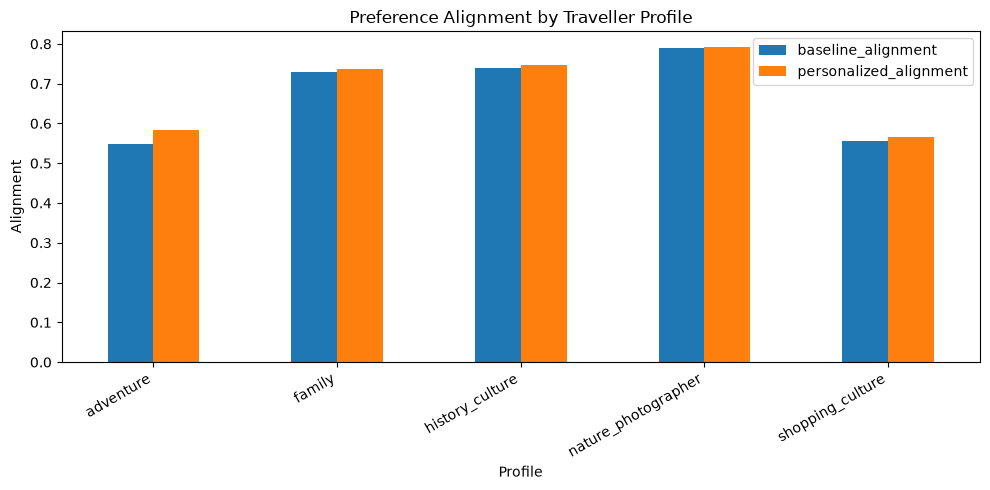

In [14]:
plot_df = profile_summary.set_index(
    "profile"
)[
    [
        "baseline_alignment",
        "personalized_alignment",
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Preference Alignment by Traveller Profile"
)

plt.ylabel(
    "Alignment"
)

plt.xlabel(
    "Profile"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


## 15. Final decision check

In [15]:
alignment_change = (
    comparison_df[
        "personalized_alignment"
    ].mean()
    - comparison_df[
        "baseline_alignment"
    ].mean()
)

city_correct = comparison_df[
    "personalized_city_correct"
].mean()

print(
    "Mean preference-alignment change:",
    round(
        alignment_change,
        4
    )
)

print(
    "Personalized city correctness:",
    round(
        city_correct,
        4
    )
)

if alignment_change > 0 and city_correct == 1.0:
    print(
        "✅ Personalized weighting shows "
        "a positive alignment change while "
        "preserving city correctness."
    )
else:
    print(
        "⚠️ Personalized weighting did not "
        "clearly improve the target metrics."
    )


Mean preference-alignment change: 0.0118
Personalized city correctness: 1.0
✅ Personalized weighting shows a positive alignment change while preserving city correctness.


## 16. Save experiment results

In [16]:
evaluation_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "evaluation"
)

evaluation_dir.mkdir(
    parents=True,
    exist_ok=True
)

summary.to_csv(
    evaluation_dir
    / "personalized_ranker_summary.csv",
    index=False,
)

comparison_df.to_csv(
    evaluation_dir
    / "personalized_ranker_comparison.csv",
    index=False,
)

profile_summary.to_csv(
    evaluation_dir
    / "personalized_ranker_profiles.csv",
    index=False,
)

sensitivity_df.to_csv(
    evaluation_dir
    / "personalized_ranker_sensitivity.csv",
    index=False,
)

print(
    f"✅ Saved results to {evaluation_dir}"
)


✅ Saved results to D:\college_work\PG\linkedIn_projects\TravelMate-AI\data\processed\evaluation


# 🏁 Notebook 23 milestone

We have now tested a second improvement strategy:

```text
Current hybrid ranking
        VS
Profile-aware weighting
```

The decision must be based on:

```text
🎯 Preference alignment
🏙️ City correctness
🧠 Personalization sensitivity
```

## Next step

If the personalized ranker wins, we promote its scoring logic into:

```text
src/recommender.py
```

Then FastAPI and Streamlit automatically inherit the improved recommendation engine.

If it does not win, we keep the current production ranking and investigate the next improvement.

> 🧠 **ML lesson:** A failed experiment is still useful when it tells you which direction not to take.
